In [3]:
import random
from pathlib import Path

random.seed(42)

base_path = Path(r"F:\EMAct")
folders = {
    "idle": base_path / "idle",
    "operational": base_path / "operational",
    "MQTT flood": base_path / "MQTT flood",
}

target_files = {
    "idle": 300,
    "operational": 500,
    "MQTT flood": 500,
}

selected_files = {}
for label, folder in folders.items():
    all_files = sorted(folder.glob("*.cfile"))
    n = target_files[label]
    if len(all_files) < n:
        print(f"⚠️ {label} only has {len(all_files)} files, using all of them")
        n = len(all_files)
    selected_files[label] = random.sample(all_files, n)
    print(f"{label}: selected {len(selected_files[label])} files")

idle: selected 300 files
operational: selected 500 files
MQTT flood: selected 500 files


In [4]:
import numpy as np
import pandas as pd

win_len = 8192
hop = win_len  # non-overlapping windows

def read_cfile(path):
    d = np.fromfile(path, dtype=np.complex64)
    d = d - d.mean()  # DC removal
    return d

def segment(d, win_len=8192, hop=None):
    if hop is None:
        hop = win_len
    n_wins = (len(d) - win_len) // hop + 1
    if n_wins <= 0:
        return np.empty((0, win_len), dtype=np.complex64)
    return np.array([d[i*hop : i*hop + win_len] for i in range(n_wins)])

def extract_features(seg):
    mag = np.abs(seg)
    power = mag**2
    nfft = len(seg)
    window = np.hanning(nfft)
    S = np.abs(np.fft.fftshift(np.fft.fft(seg * window)))**2
    Sdb = 10*np.log10(S + 1e-20)
    freqs = np.fft.fftshift(np.fft.fftfreq(nfft))
    centroid = np.sum(freqs * S) / (np.sum(S) + 1e-20)

    feats = {
        'mean_power': power.mean(),
        'std_power': power.std(),
        'peak_power': power.max(),
        'papr_db': 10*np.log10(power.max() / (power.mean()+1e-20)),
        'crest_factor': mag.max() / (mag.mean()+1e-20),
        'skewness': ((mag - mag.mean())**3).mean() / (mag.std()**3 + 1e-20),
        'kurtosis': ((mag - mag.mean())**4).mean() / (mag.std()**4 + 1e-20),
        'spectral_peak_db': Sdb.max(),
        'spectral_peak_freq': freqs[np.argmax(S)],
        'spectral_centroid': centroid,
        'spectral_flatness': np.exp(np.mean(np.log(S + 1e-20))) / (np.mean(S) + 1e-20),
        'spectral_bandwidth': np.sqrt(np.sum(((freqs - centroid)**2) * S) / (np.sum(S)+1e-20)),
    }

    # band energy ratios
    n_bands = 8
    band_edges = np.linspace(0, nfft, n_bands+1, dtype=int)
    total_energy = S.sum() + 1e-20
    for i in range(n_bands):
        feats[f'band_energy_{i}'] = S[band_edges[i]:band_edges[i+1]].sum() / total_energy

    return feats

rows = []
for label, files in selected_files.items():
    for fpath in files:
        d = read_cfile(fpath)
        segs = segment(d, win_len=win_len, hop=hop)
        for seg in segs:
            feats = extract_features(seg)
            feats['label'] = label
            feats['file'] = fpath.name
            rows.append(feats)

df = pd.DataFrame(rows)
print(df.shape)
print(df['label'].value_counts())
df.to_csv("features.csv", index=False)

(354316, 22)
MQTT flood     137558
operational    137516
idle            79242
Name: label, dtype: int64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("features.csv")
feature_cols = [c for c in df.columns if c not in ('label', 'file')]
print("Columns:", df.columns.tolist())
print("Number of features:", len(feature_cols))

Columns: ['mean_power', 'std_power', 'peak_power', 'papr_db', 'crest_factor', 'skewness', 'kurtosis', 'spectral_peak_db', 'spectral_peak_freq', 'spectral_centroid', 'spectral_flatness', 'spectral_bandwidth', 'band_energy_0', 'band_energy_1', 'band_energy_2', 'band_energy_3', 'band_energy_4', 'band_energy_5', 'band_energy_6', 'band_energy_7', 'label', 'file']
Number of features: 20


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("features.csv")
feature_cols = [c for c in df.columns if c not in ('label', 'file')]

# quick numeric summary per class
print(df.groupby('label')[feature_cols].mean().round(4).T)

label               MQTT flood     idle  operational
mean_power              0.0049   0.0004       0.0049
std_power               0.0036   0.0004       0.0033
peak_power              0.0269   0.0046       0.0236
papr_db                 7.8591   9.9800       8.6447
crest_factor            2.6847   3.5542       3.0731
skewness                0.3601   0.6753       0.5766
kurtosis                3.0182   3.9792       3.9872
spectral_peak_db       42.4326  32.8930      41.4594
spectral_peak_freq      0.0008   0.0020       0.0008
spectral_centroid      -0.0055   0.0174       0.0047
spectral_flatness       0.1917   0.2559       0.1982
spectral_bandwidth      0.1608   0.1842       0.1563
band_energy_0           0.0366   0.0350       0.0277
band_energy_1           0.0583   0.0619       0.0493
band_energy_2           0.0481   0.0617       0.0532
band_energy_3           0.0498   0.0686       0.0529
band_energy_4           0.6819   0.5528       0.6785
band_energy_5           0.0474   0.0980       

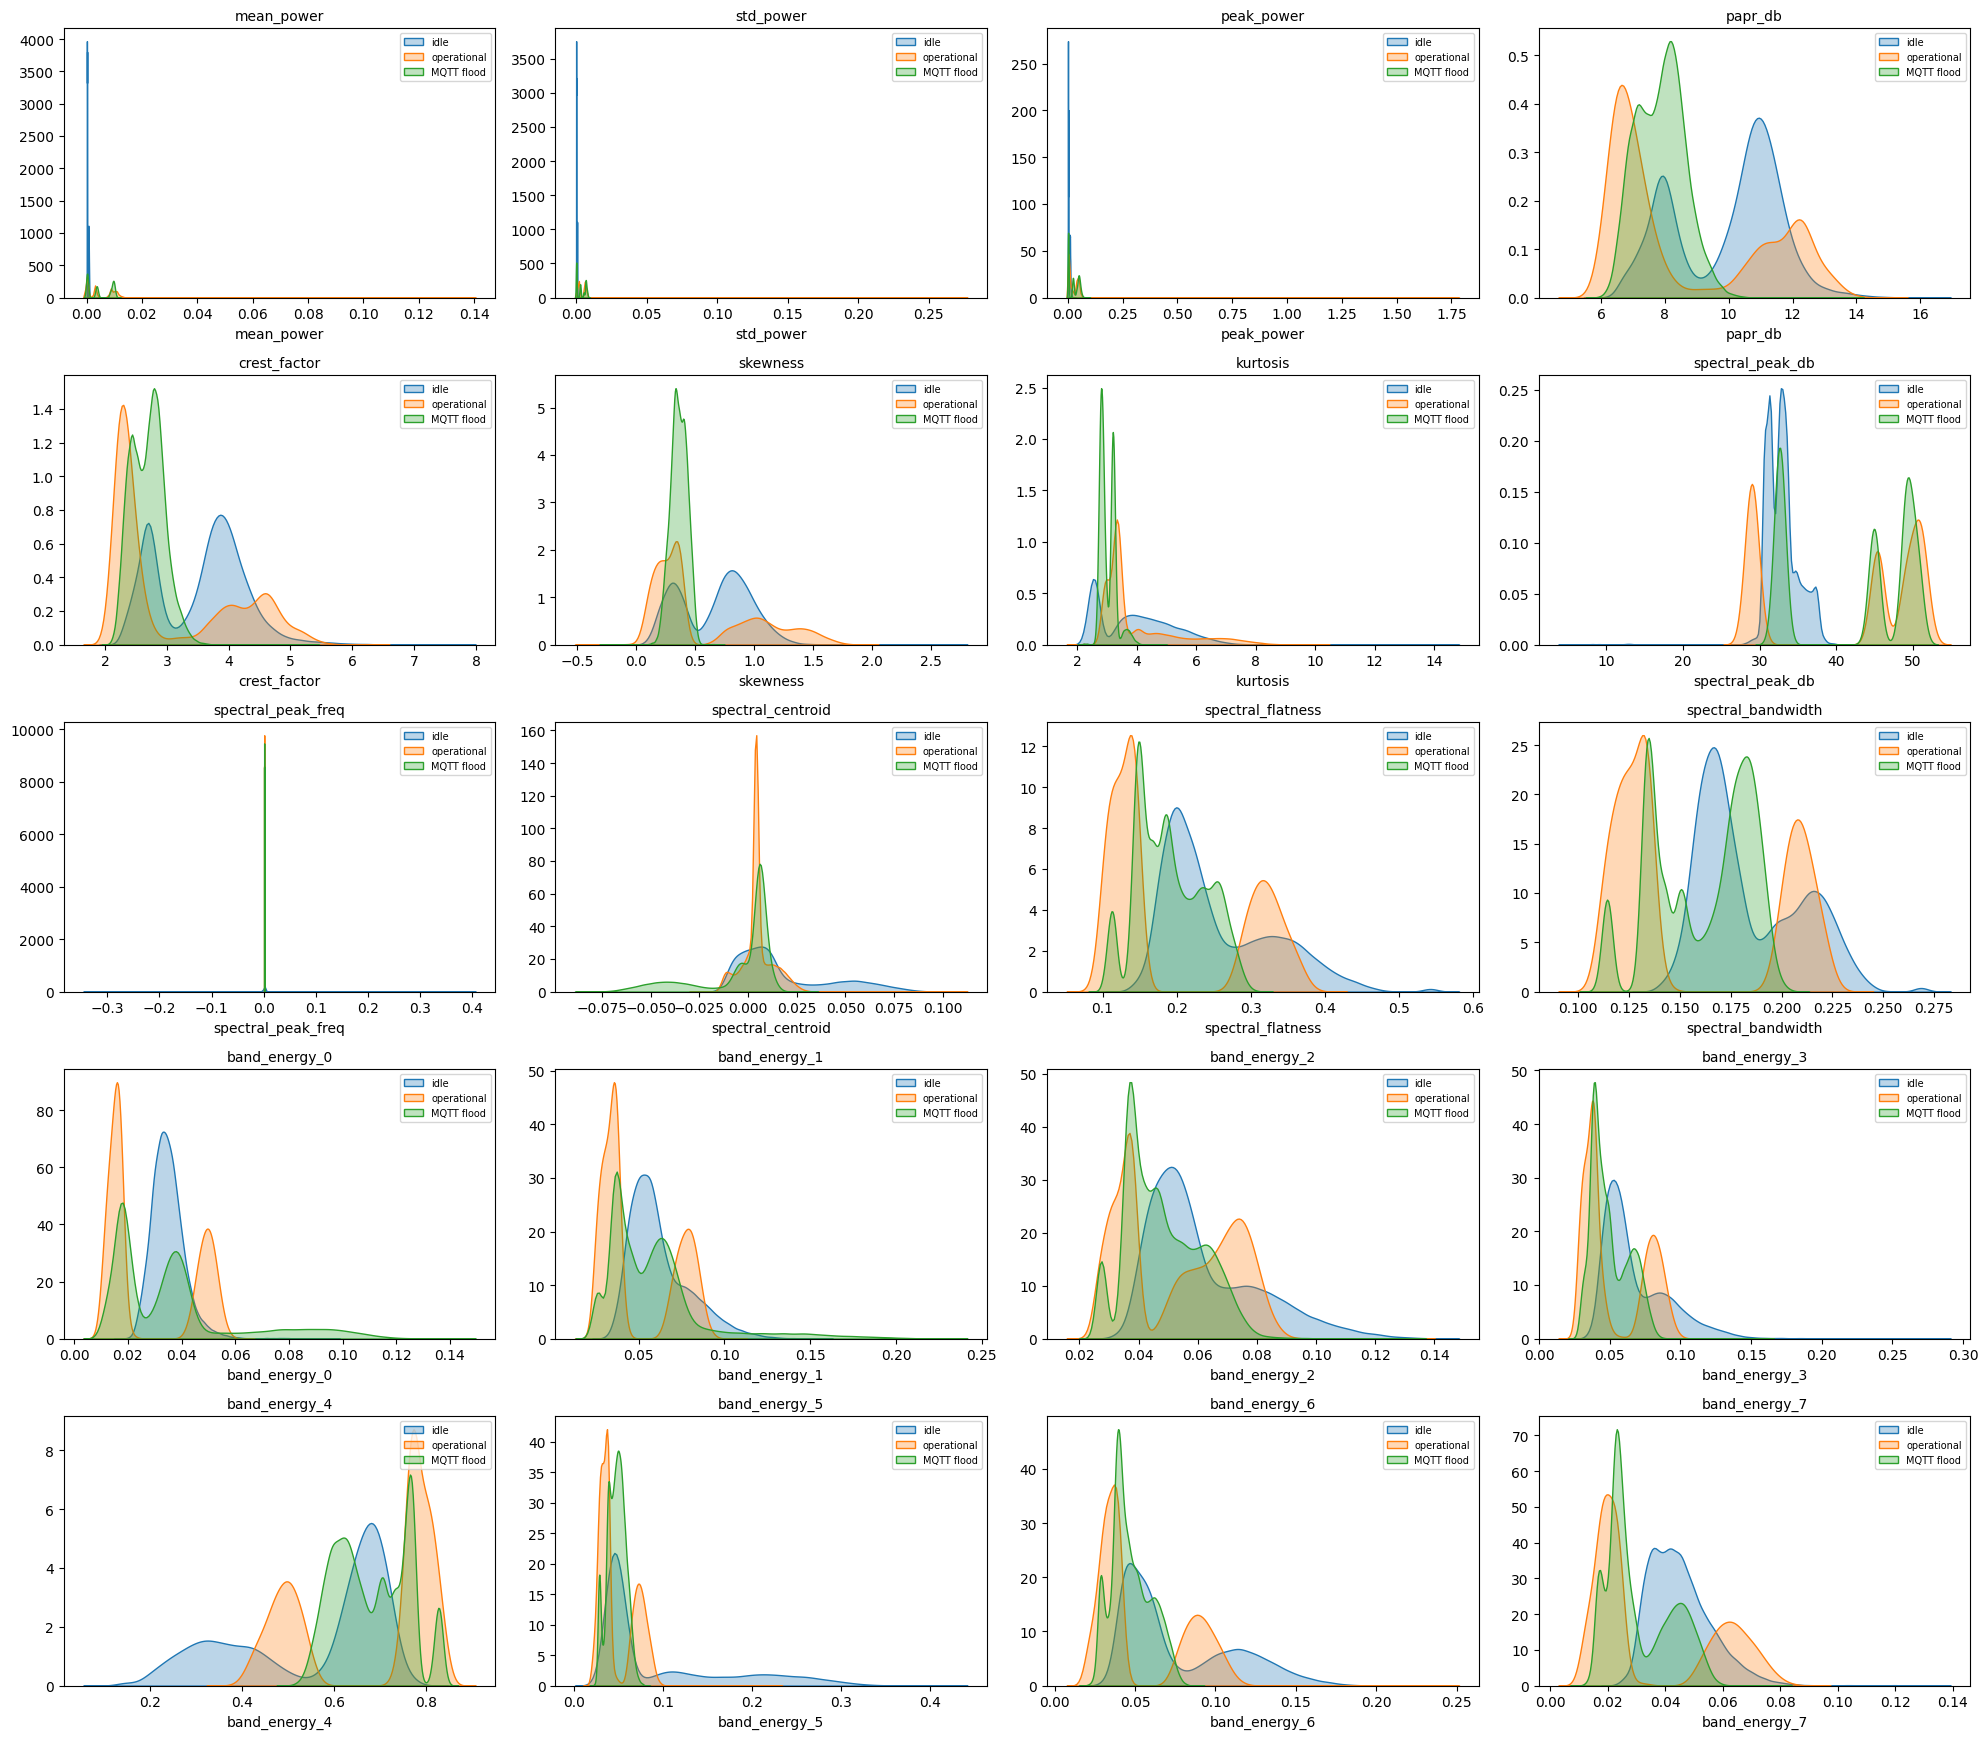

In [7]:
# --- KDE distribution plot per feature, split by class ---
n_cols = 4
n_rows = -(-len(feature_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    for label in df['label'].unique():
        subset = df[df['label'] == label][feat]
        sns.kdeplot(subset, label=label, ax=ax, fill=True, alpha=0.3, warn_singular=False)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_ylabel("")

for j in range(len(feature_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=120)
plt.show()

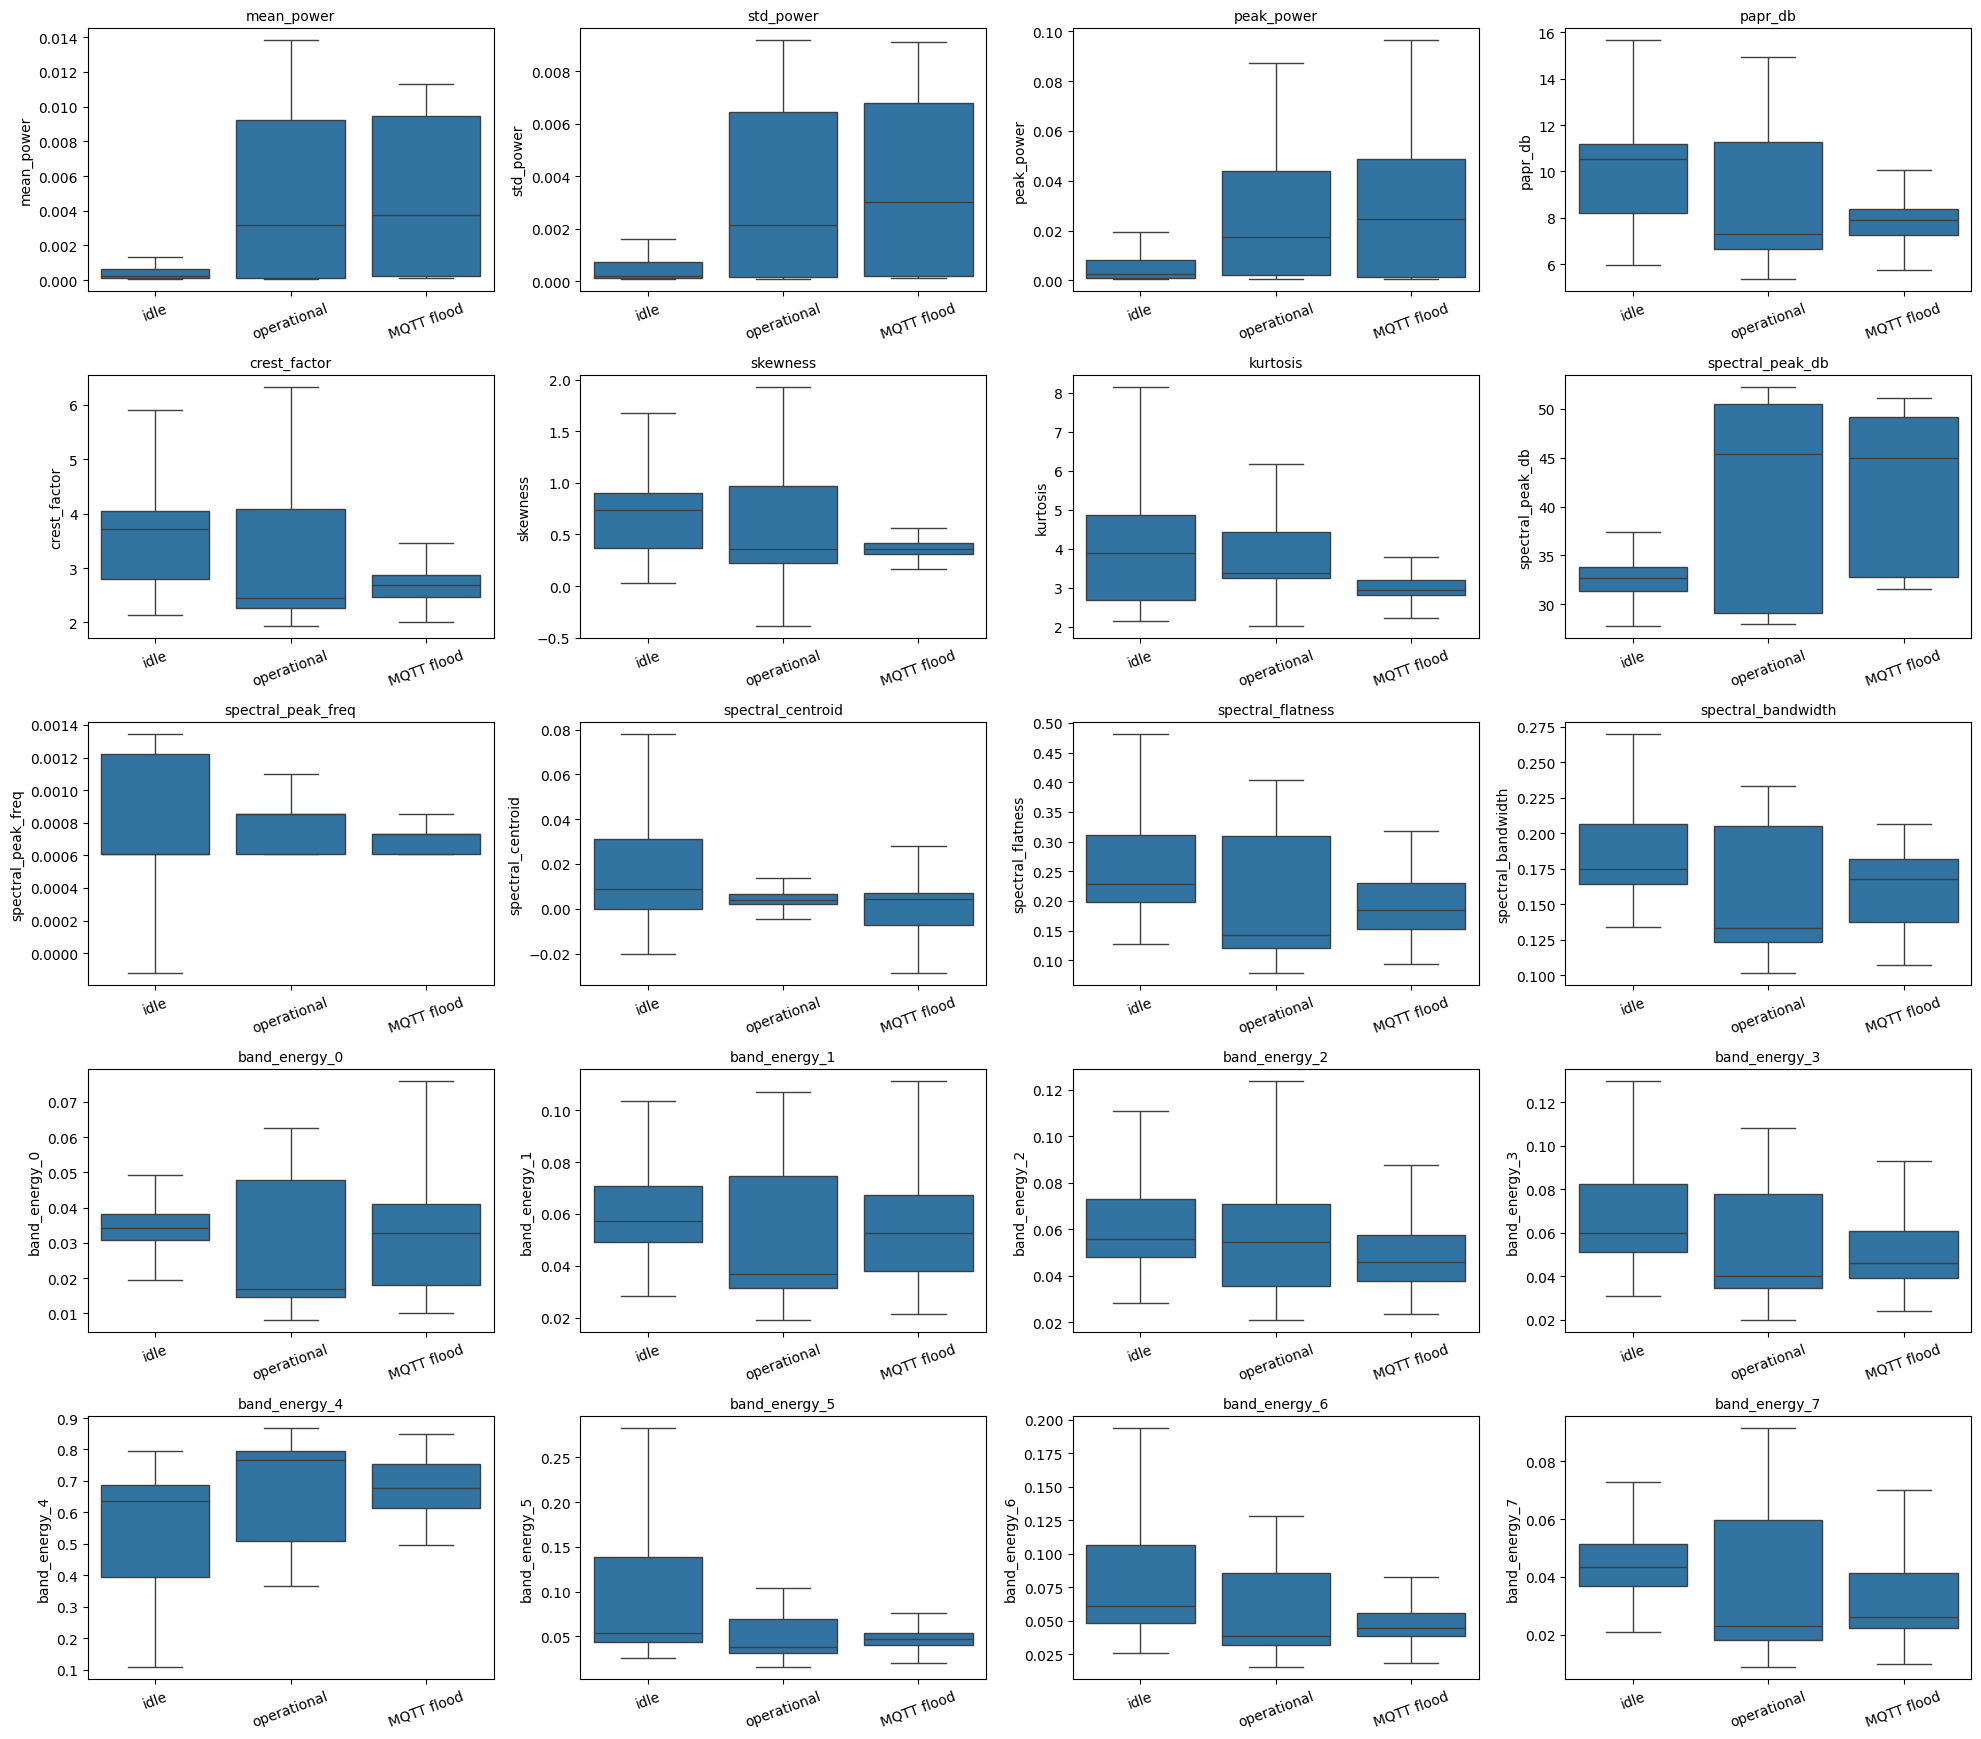

In [8]:
# --- Boxplots (good for spotting outliers/scale issues) ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3.5*n_rows))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='label', y=feat, ax=ax, showfliers=False)  # hide extreme outliers for readability
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

for j in range(len(feature_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig("feature_boxplots.png", dpi=120)
plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("features.csv")

feature_cols = [c for c in df.columns if c not in ('label', 'file')]
X = df[feature_cols].values
y = df['label'].values
groups = df['file'].values  # ensures segments from same file stay together

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# sanity check: no file appears in both train and test
train_files = set(groups[train_idx])
test_files = set(groups[test_idx])
print("Overlap between train/test files (should be 0):", len(train_files & test_files))

print("Train segments:", len(X_train), " Test segments:", len(X_test))
print("Train class distribution:\n", pd.Series(y_train).value_counts())
print("Test class distribution:\n", pd.Series(y_test).value_counts())

Overlap between train/test files (should be 0): 0
Train segments: 283478  Test segments: 70838
Train class distribution:
 operational    111374
MQTT flood     109746
idle            62358
dtype: int64
Test class distribution:
 MQTT flood     27812
operational    26142
idle           16884
dtype: int64


In [10]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',   # compensates for idle having fewer files
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

spectral_peak_db      0.149762
mean_power            0.121467
spectral_peak_freq    0.101445
std_power             0.097585
spectral_flatness     0.070922
peak_power            0.067210
spectral_bandwidth    0.059727
kurtosis              0.058584
band_energy_0         0.050946
skewness              0.048194
band_energy_4         0.034855
crest_factor          0.026314
band_energy_7         0.022637
band_energy_5         0.021945
papr_db               0.020513
spectral_centroid     0.012691
band_energy_1         0.012450
band_energy_6         0.008131
band_energy_2         0.008045
band_energy_3         0.006577
dtype: float64


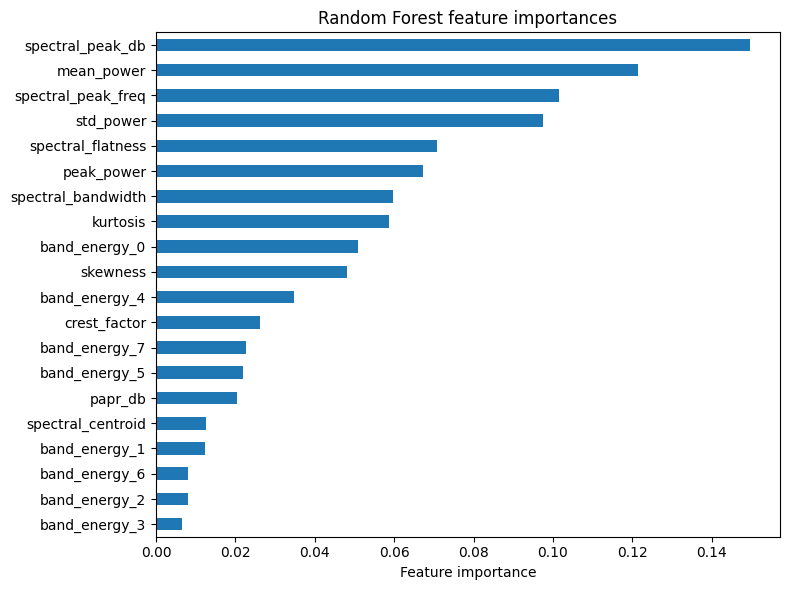

In [11]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  MQTT flood       1.00      1.00      1.00     27812
        idle       1.00      1.00      1.00     16884
 operational       1.00      1.00      1.00     26142

    accuracy                           1.00     70838
   macro avg       1.00      1.00      1.00     70838
weighted avg       1.00      1.00      1.00     70838



In [13]:
# Retrain WITHOUT the dominant power/idle-related features, see if operational vs MQTT flood alone still separates well
drop_feats = ['mean_power', 'peak_power', 'std_power', 'spectral_peak_db', 'spectral_peak_freq']
reduced_feats = [f for f in feature_cols if f not in drop_feats]

X_train_r = df.loc[train_idx, reduced_feats].values
X_test_r = df.loc[test_idx, reduced_feats].values

clf_r = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
clf_r.fit(X_train_r, y_train)
y_pred_r = clf_r.predict(X_test_r)
print(classification_report(y_test, y_pred_r))

              precision    recall  f1-score   support

  MQTT flood       0.98      0.96      0.97     27812
        idle       0.99      0.99      0.99     16884
 operational       0.96      0.99      0.97     26142

    accuracy                           0.98     70838
   macro avg       0.98      0.98      0.98     70838
weighted avg       0.98      0.98      0.98     70838



In [14]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score

X_reduced = df[reduced_feats].values

gkf = GroupKFold(n_splits=5)
scores = []
for tr_idx, te_idx in gkf.split(X_reduced, y, groups):
    clf_cv = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
    clf_cv.fit(X_reduced[tr_idx], y[tr_idx])
    pred = clf_cv.predict(X_reduced[te_idx])
    scores.append(accuracy_score(y[te_idx], pred))

print("Fold accuracies:", scores)
print("Mean:", sum(scores)/len(scores))

Fold accuracies: [0.9748871331828443, 0.9768199774266366, 0.975507900677201, 0.9778649877184562, 0.9779779214545865]
Mean: 0.976611584091945


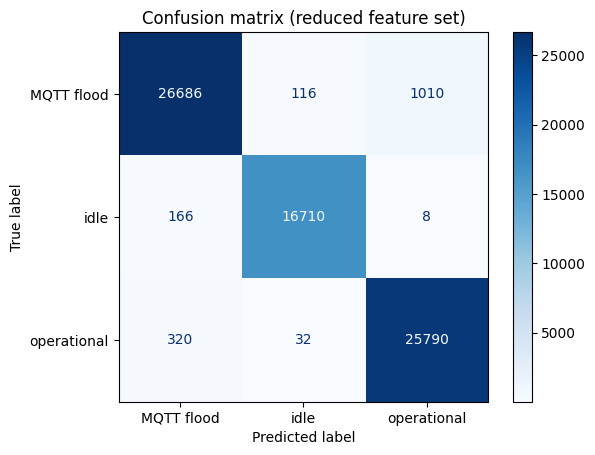

In [15]:
cm = confusion_matrix(y_test, y_pred_r, labels=clf_r.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_r.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion matrix (reduced feature set)")
plt.show()

In [16]:
import time
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Use the same reduced feature set (without the 5 dominant power features)
# so all models are compared fairly on the same, already-validated feature set
X_train_r = df.loc[train_idx, reduced_feats].values
X_test_r  = df.loc[test_idx, reduced_feats].values
y_train   = df.loc[train_idx, 'label'].values
y_test    = df.loc[test_idx, 'label'].values

# Most non-tree models need scaled features; RF/GBM don't require it but it doesn't hurt
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_r)
X_test_scaled = scaler.transform(X_test_r)

models = {
    "Random Forest (baseline)": (RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1), X_train_r, X_test_r),
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X_train_scaled, X_test_scaled),
    "Linear SVM": (LinearSVC(class_weight='balanced', random_state=42, max_iter=5000), X_train_scaled, X_test_scaled),
    "KNN (k=5)": (KNeighborsClassifier(n_neighbors=5, n_jobs=-1), X_train_scaled, X_test_scaled),
    "Gradient Boosting": (GradientBoostingClassifier(n_estimators=200, random_state=42), X_train_r, X_test_r),
}

results = []
for name, (model, Xtr, Xte) in models.items():
    start = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - start

    y_pred = model.predict(Xte)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "train_time_sec": round(train_time, 1),
    })
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
print("\n\nModel comparison summary:")
print(results_df.to_string(index=False))


=== Random Forest (baseline) ===
              precision    recall  f1-score   support

  MQTT flood       0.98      0.96      0.97     27812
        idle       0.99      0.99      0.99     16884
 operational       0.96      0.99      0.97     26142

    accuracy                           0.98     70838
   macro avg       0.98      0.98      0.98     70838
weighted avg       0.98      0.98      0.98     70838


=== Logistic Regression ===
              precision    recall  f1-score   support

  MQTT flood       0.78      0.76      0.77     27812
        idle       0.72      0.77      0.74     16884
 operational       0.87      0.86      0.86     26142

    accuracy                           0.80     70838
   macro avg       0.79      0.79      0.79     70838
weighted avg       0.80      0.80      0.80     70838


=== Linear SVM ===
              precision    recall  f1-score   support

  MQTT flood       0.77      0.81      0.79     27812
        idle       0.80      0.69      0.74   

In [17]:
import numpy as np
import pandas as pd
from pathlib import Path
import random

random.seed(42)

base_path = Path(r"F:\EMAct")
folders = {
    "idle": base_path / "idle",
    "operational": base_path / "operational",
    "MQTT flood": base_path / "MQTT flood",
}
target_files = {"idle": 300, "operational": 500, "MQTT flood": 500}

win_len = 8192
bytes_per_sample = 8  # complex64

index_rows = []
for label, folder in folders.items():
    files = sorted(folder.glob("*.cfile"))
    n = target_files[label]
    files = random.sample(files, min(n, len(files)))
    for fpath in files:
        file_size = fpath.stat().st_size
        n_samples = file_size // bytes_per_sample
        n_segments = (n_samples - win_len) // win_len + 1
        for seg_idx in range(n_segments):
            index_rows.append({
                "file": str(fpath),
                "seg_offset": seg_idx * win_len,   # offset in SAMPLES
                "label": label,
            })

index_df = pd.DataFrame(index_rows)
print(index_df.shape)
print(index_df['label'].value_counts())
index_df.to_csv("cnn_segment_index.csv", index=False)

(354316, 3)
MQTT flood     137558
operational    137516
idle            79242
Name: label, dtype: int64


In [18]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(index_df, index_df['label'], groups=index_df['file']))

train_df = index_df.iloc[train_idx].reset_index(drop=True)
test_df = index_df.iloc[test_idx].reset_index(drop=True)

overlap = set(train_df['file']) & set(test_df['file'])
print("File overlap (should be 0):", len(overlap))
print("Train segments:", len(train_df), " Test segments:", len(test_df))

File overlap (should be 0): 0
Train segments: 283772  Test segments: 70544
